<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB44 · Moldear la recompensa: andar bonito

**Parte 6 · Bípedos de verdad — Lección 1**

> En el **NB43** Zancudo aprendió a moverse hacia delante... a su manera. Su recompensa decía "avanza todo lo que puedas sin caerte", y eso hizo: **corre** a más de 4 m/s, a grandes zancadas, con patadas en las que el pie sube más de medio metro y pasando más de la mitad del tiempo **en el aire** (lo mediremos en la sección 6).

Empieza la **Parte 6 · Bípedos de verdad**, y empieza por el problema que destapó el NB43: el agente hace **lo que le pagas**, no lo que quieres (NB04, NB35). Si queremos un robot que **ande** (que no corra), a una velocidad **razonable**, con el torso **recto**, sin **patadas** y con movimientos **suaves** (para no romper sus motores, NB40), hay que **decírselo** en la recompensa.

A eso se le llama **moldear la recompensa** (*reward shaping*), y es, probablemente, la parte del trabajo de un ingeniero de locomoción que más horas se come. Hoy vamos a moldear la de Zancudo con cinco términos, a entrenarla, y a hacer un **estudio de ablación** (quitar los términos uno a uno) para ver qué hace cada pieza.


## 1 · Por qué corría

Recuerda la recompensa del NB43:

```
   recompensa  =  velocidad hacia delante  +  1  −  0,01 × acciones²
```

Cada metro por segundo de más es un punto más **en cada paso**. No hay ningún límite: a 4 m/s se cobran 5 puntos por paso, a 2 m/s solo 3. Así que PPO buscó la forma de ir **lo más rápido posible**, y la encontró: correr a saltos. Nada en la recompensa dice "no corras", ni "no levantes el pie un metro", ni "no vayas a tirones".

Es el **reward hacking** del NB04 en estado puro, aunque esta vez el "hackeo" sea casi admirable: un robot plano de 23 kg que corre a 16 km/h. Pero un robot **real** que corriera así se rompería: los aterrizajes de cada salto golpean los motores (NB40), las patadas gastan muchísima energía (y calientan los motores, NB40), y depender de pasar media vida en el aire hace que cualquier diferencia entre la simulación y la realidad lo tire al suelo (el reality gap, NB02).


## 2 · Moldear: añadir términos, con cuidado

Moldear la recompensa es **añadir términos** que premian lo que queremos y castigan lo que no, cada uno con su **peso** (cuánto importa):

```
   recompensa  =  peso₁ × término₁  +  peso₂ × término₂  +  ...  −  pesoₖ × castigoₖ  −  ...
```

Suena fácil, pero tiene tres peligros, y los tres los vas a ver hoy:

1. **Cada término nuevo es una trampa nueva** (la ley de **Goodhart** del NB04: "cuando una medida se convierte en objetivo, deja de ser una buena medida"). Si castigas "levantar el pie más de 15 cm", quizá aprenda a arrastrar los pies. Si castigas "estar en el aire", quizá aprenda a dar pasitos ridículos.
2. **Los pesos importan muchísimo.** Un castigo demasiado fuerte y el robot prefiere no moverse; demasiado débil, y lo ignora. Encontrar los pesos es, a menudo, prueba y error.
3. **La trampa de sobrevivir** (NB35) sigue ahí: si quedarse quieto paga más que intentar andar con todos los castigos, se quedará quieto.

Por eso, después de moldear hay que **mirar** (los GIF, no solo la nota) y **medir** cada cosa que queríamos conseguir.


## 3 · Seguir un objetivo: la campana

La primera idea es la más importante: no queremos "la velocidad **máxima**", sino "**1 m/s**". El término de velocidad del NB43 (cobrar la velocidad tal cual) premia ir siempre más rápido. Necesitamos un término que valga **lo máximo justo en 1 m/s** y **menos** cuanto más nos alejemos, por arriba o por abajo.

La herramienta que usa todo el mundo es la **campana** del NB28, en forma de **núcleo exponencial**:

```
   término de velocidad  =  e^( −(velocidad − objetivo)² / 0,25 )
```

- Si la velocidad es **justo** el objetivo, la diferencia es 0, y e⁰ = **1**: el máximo.
- Si se aleja, la diferencia al cuadrado crece, el exponente se hace muy negativo, y el término cae hacia **0**.
- El 0,25 (el "ancho" de la campana) decide **cuánto** se tolera: aquí, alejarse medio metro por segundo ya baja el premio a e⁻¹ ≈ 0,37.

Dibujémoslo, junto al término del NB43:


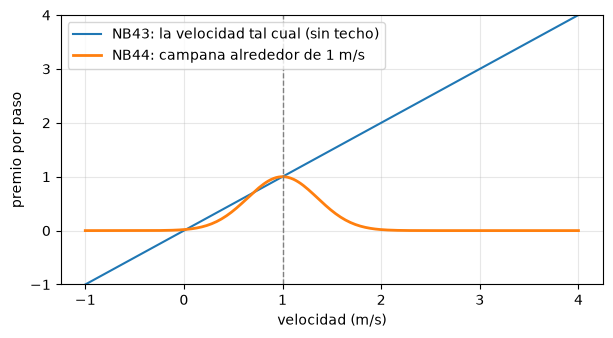

In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"
import numpy as np
import matplotlib.pyplot as plt

velocidades = np.linspace(-1, 4, 200)
plt.figure(figsize=(7, 3.5))
plt.plot(velocidades, velocidades, label="NB43: la velocidad tal cual (sin techo)")
plt.plot(velocidades, np.exp(-(velocidades - 1.0) ** 2 / 0.25), lw=2, label="NB44: campana alrededor de 1 m/s")
plt.axvline(1.0, color="gray", ls="--", lw=1)
plt.ylim(-1, 4)
plt.xlabel("velocidad (m/s)")
plt.ylabel("premio por paso")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Con la campana, correr a 4 m/s ya no paga **nada** (e^(−9 / 0,25) ≈ 0), y quedarse quieto tampoco (e^(−1 / 0,25) ≈ 0,02). Lo que más paga es ir **justo** a 1 m/s. Este truco (premiar con una campana la cercanía a un objetivo) es el que usan casi todos los entornos de robots con patas modernos para que **sigan órdenes** de velocidad, como veremos en el NB46. Y vale para cualquier cosa que queramos **mantener cerca** de un valor: una altura, una inclinación, un ángulo...


## 4 · Los cinco términos de Zancudo

El entorno con la recompensa moldeada está en `zancudo_moldeado.py`. Es una **subclase** de `Zancudo` (la herencia del NB25): lo hereda **todo** (el robot, la observación, la acción, las caídas) y solo cambia la recompensa. Leamos su `step` con `inspect` (NB43):


In [2]:
import inspect
import gymnasium as gym
import zancudo_moldeado
from zancudo_moldeado import ZancudoMoldeado

print(inspect.getsource(ZancudoMoldeado.step))

    def step(self, accion):
        observacion, _, caido, truncado, info = super().step(accion)
        p = self.pesos
        accion = np.clip(accion, -1, 1)
        # 1. ir a la velocidad pedida: 1 si va justo a esa velocidad, menos cuanto más se aleje (campana, NB28)
        r_velocidad = np.exp(-((info["velocidad"] - self.velocidad_objetivo) ** 2) / 0.25)
        # 2. torso recto: 1 si está recto, menos cuanto más se incline
        r_recto = np.exp(-(self.datos.qpos[2] ** 2) / 0.05)
        # 3. andar, no correr: castigo si NINGÚN pie toca el suelo
        tocan = self.pies_en_el_suelo()
        en_el_aire = 0.0 if any(tocan) else 1.0
        # 4. no dar patadas: castigo si un pie sube más de 15 cm
        alturas = np.array([self.datos.geom_xpos[pie][2] for pie in self.pies])
        exceso = float(np.sum(np.clip(alturas - 0.15, 0, None)))
        # 5. movimientos suaves: castigo por cambiar mucho la acción de una decisión a la siguiente
        cambio = float(np.sum((accion - s

Primero llama al `step` de su madre con `super().step(accion)` (NB25): así el robot se mueve exactamente igual que en el NB43, y nos quedamos con su observación, sus caídas y su `info`, pero **tiramos** su recompensa (el `_`). Después calcula cinco términos:

| Término | Qué mide | Tipo | Peso |
|---|---|---|---|
| **velocidad** | cercanía a 1 m/s (campana) | premio, de 0 a 1 | 1,0 |
| **recto** | cercanía del torso a la vertical (campana) | premio, de 0 a 1 | 0,3 |
| **vida** | seguir vivo | premio fijo | 0,2 |
| **vuelo** | 1 si **ningún** pie toca el suelo | castigo | 0,5 |
| **pie_alto** | cuánto pasan los pies de 15 cm de altura | castigo | 2,0 |
| **suavidad** | cuánto cambia la acción respecto de la anterior (al cuadrado) | castigo | 0,05 |

Algunos detalles:

- **Vuelo**: queremos **andar**, y andar es, por definición, tener siempre al menos un pie en el suelo (correr es justo lo contrario: hay fases en el aire, NB35). Para saber qué pie toca el suelo, mira la lista de **contactos** de MuJoCo, como en el NB41:


In [3]:
print(inspect.getsource(ZancudoMoldeado.pies_en_el_suelo))

    def pies_en_el_suelo(self):
        # ¿qué pies tocan el suelo? Miramos la lista de contactos (NB41)
        tocan = [False, False]
        for i in range(self.datos.ncon):
            c = self.datos.contact[i]
            for k, pie in enumerate(self.pies):
                if (c.geom1 == pie and c.geom2 == self.suelo) or (c.geom2 == pie and c.geom1 == self.suelo):
                    tocan[k] = True
        return tocan



- **Pie alto**: los pies pueden subir hasta 15 cm sin castigo (lo necesario para no tropezar). Lo que pase de ahí, se castiga: adiós a las patadas de medio metro.
- **Suavidad**: compara la acción de ahora con la de la decisión anterior. Un robot que cambia de golpe sus ángulos objetivo a cada decisión pega **tirones** a sus motores (y en el mundo real, eso hace vibrar la estructura y calienta los motores, NB40). Este término es uno de los más usados en robots reales.
- La **vida** ahora vale 0,2 (antes, 1): ya no queremos que sobrevivir sea lo principal.

¿Le sale a cuenta quedarse quieto? Hagamos las cuentas por paso (sin castigos, en el mejor de los casos):

- **Quieto y recto**: velocidad ≈ 0,02 + recto 0,3 + vida 0,2 ≈ **0,52** por paso → unos **520** puntos en los 1.000 pasos.
- **Andando a 1 m/s, recto**: 1 + 0,3 + 0,2 = **1,5** por paso → **1.500** puntos.

Andar paga el triple. La trampa de sobrevivir está desactivada... sobre el papel. Comprobemos las políticas de referencia:


In [4]:
from gymnasium.utils.env_checker import check_env
check_env(ZancudoMoldeado())

moldeado = gym.make("ZancudoMoldeado-v0")

def jugar_episodios(entorno, politica, n=5):
    retornos, duraciones, distancias = [], [], []
    for semilla in range(n):
        observacion, info = entorno.reset(seed=semilla)
        retorno, pasos = 0.0, 0
        while True:
            observacion, recompensa, terminado, truncado, info = entorno.step(politica(observacion))
            retorno += recompensa
            pasos += 1
            if terminado or truncado:
                break
        retornos.append(retorno)
        duraciones.append(pasos)
        distancias.append(info["x"])
    return np.mean(retornos), np.mean(duraciones), np.mean(distancias)

for nombre, politica in [("quieto", lambda obs: np.zeros(6)), ("azar", lambda obs: moldeado.action_space.sample())]:
    r, d, x = jugar_episodios(moldeado, politica)
    print(f"{nombre:>6}: retorno {r:6.1f} | dura {d:6.1f} pasos | acaba en x = {x:+.2f} m")

/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:317: UserWarning: WARN: A Box observation space minimum value is -infinity. This is probably too low.
  logger.warn(
/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:321: UserWarning: WARN: A Box observation space maximum value is infinity. This is probably too high.
  logger.warn(
/home/gregori/dev/robotica/venv/lib/python3.13/site-packages/gymnasium/utils/env_checker.py:440: UserWarning: WARN: Not able to test alternative render modes due to the environment not having a spec. Try instantiating the environment through `gymnasium.make`
  logger.warn(


quieto: retorno  322.6 | dura  665.6 pasos | acaba en x = -0.07 m
  azar: retorno    1.8 | dura   60.8 pasos | acaba en x = +0.01 m


(`check_env` no se queja: solo da los avisos de siempre, NB43.)

- **Quieto: 322,6 puntos.** Con solo 5 episodios, y en 2 de ellos se cae de espaldas (las semillas 0 y 2, como en el NB43; por eso dura 665,6 pasos de media). En los 3 en que aguanta de pie, cobra unos **500** puntos, lo que predecían las cuentas.
- **Azar: unos 2 puntos.** (La cifra exacta cambia en cada ejecución: `action_space.sample()` no usa la semilla del `reset`.) Agitarse al azar ya no da casi nada: se cae en un segundo o poco más, y los castigos de **suavidad** (cada decisión al azar es un tirón enorme) y de **vuelo** se comen los pocos premios.

El listón ahora es: **andar a 1 m/s, recto, sin castigos**, rondaría los **1.500** puntos.


## 5 · El estudio de ablación

¿Hace falta cada uno de los términos? La forma científica de saberlo es un **estudio de ablación** ("ablación" viene de quitar, extirpar): entrenar con **todos** los términos, y después repetir **quitando** uno (o un grupo) cada vez. Si al quitar un término el robot empeora justo en lo que ese término vigilaba, es que hacía falta. Es lo que se hace en cualquier artículo de investigación serio, y lo que te van a preguntar en una entrevista de trabajo: "¿y cómo sabes que ese término sirve para algo?".

Entrené cuatro variantes con el script `entrenar_moldeado.py` (junto a este notebook), PPO con los ajustes por defecto y `VecNormalize`, cuatro a la vez en la Pi, como en el NB43:

| Variante | Qué cambia |
|---|---|
| `completa` | los cinco términos, objetivo 1 m/s |
| `sin_vuelo` | sin el castigo por tener los dos pies en el aire |
| `sin_pie_alto` | sin los castigos de pie alto ni de suavidad |
| `lento` | completa, pero pidiendo **0,5 m/s** |

Sus registros (pasos, nota, desviación, distancia en los 20 s, duración media del episodio en pasos):


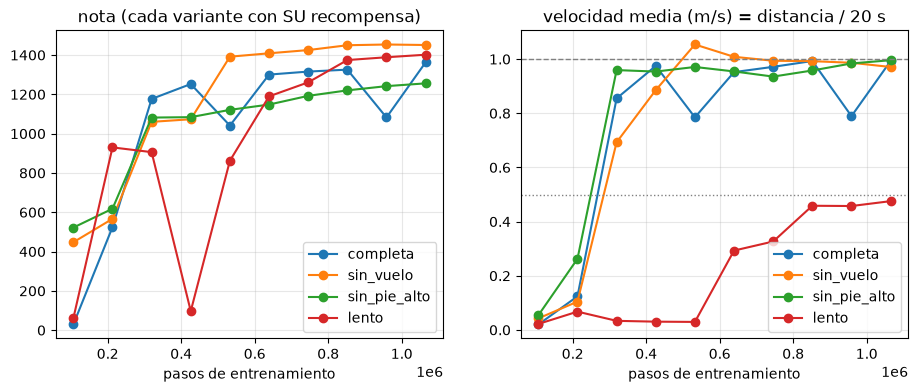

In [5]:
# (pasos, nota media de 5 episodios, desviación, distancia media en m, duración media en pasos) de cada tramo
completa = [(106_496, 29.0, 3.2, 0.4, 45.8), (212_992, 524.3, 13.0, 2.48, 1000.0), (319_488, 1176.6, 20.0, 17.1, 1000.0),
            (425_984, 1252.4, 14.6, 19.5, 1000.0), (532_480, 1041.0, 506.4, 15.7, 806.2), (638_976, 1300.5, 10.6, 19.04, 1000.0),
            (745_472, 1315.8, 7.4, 19.43, 1000.0), (851_968, 1325.7, 3.4, 19.86, 1000.0), (958_464, 1082.3, 524.7, 15.79, 806.4),
            (1_064_960, 1362.7, 3.5, 19.86, 1000.0)]
sin_vuelo = [(106_496, 447.5, 170.8, 0.85, 830.2), (212_992, 566.6, 5.5, 2.09, 1000.0), (319_488, 1060.0, 57.4, 13.86, 1000.0),
             (425_984, 1073.3, 534.0, 17.71, 803.8), (532_480, 1391.6, 4.4, 21.08, 1000.0), (638_976, 1408.8, 3.8, 20.17, 1000.0),
             (745_472, 1425.2, 7.8, 19.88, 1000.0), (851_968, 1449.8, 2.1, 19.85, 1000.0), (958_464, 1453.6, 2.4, 19.73, 1000.0),
             (1_064_960, 1451.0, 6.5, 19.42, 1000.0)]
sin_pie_alto = [(106_496, 522.1, 4.5, 1.08, 1000.0), (212_992, 618.0, 38.5, 5.25, 1000.0), (319_488, 1081.8, 11.0, 19.19, 1000.0),
                (425_984, 1083.9, 10.5, 19.08, 1000.0), (532_480, 1121.1, 6.3, 19.42, 1000.0), (638_976, 1148.0, 24.9, 19.09, 1000.0),
                (745_472, 1192.3, 12.5, 18.71, 1000.0), (851_968, 1220.2, 7.3, 19.16, 1000.0), (958_464, 1241.7, 12.1, 19.68, 1000.0),
                (1_064_960, 1255.9, 9.5, 19.92, 1000.0)]
lento = [(106_496, 60.3, 12.7, 0.44, 53.8), (212_992, 930.0, 20.7, 1.35, 1000.0), (319_488, 906.0, 6.0, 0.67, 1000.0),
         (425_984, 97.0, 12.5, 0.61, 81.4), (532_480, 862.2, 10.2, 0.59, 1000.0), (638_976, 1189.8, 100.3, 5.86, 1000.0),
         (745_472, 1261.0, 31.2, 6.53, 1000.0), (851_968, 1374.4, 6.0, 9.17, 1000.0), (958_464, 1388.7, 5.6, 9.15, 1000.0),
         (1_064_960, 1401.6, 7.9, 9.51, 1000.0)]

fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 4))
for nombre, registro in [("completa", completa), ("sin_vuelo", sin_vuelo), ("sin_pie_alto", sin_pie_alto), ("lento", lento)]:
    pasos = [p for p, *resto in registro]
    izq.plot(pasos, [nota for p, nota, *resto in registro], marker="o", label=nombre)
    der.plot(pasos, [x / 20 for p, nota, d, x, dur in registro], marker="o", label=nombre)
izq.set_title("nota (cada variante con SU recompensa)")
izq.set_xlabel("pasos de entrenamiento")
der.set_title("velocidad media (m/s) = distancia / 20 s")
der.axhline(1.0, color="gray", ls="--", lw=1)
der.axhline(0.5, color="gray", ls=":", lw=1)
der.set_xlabel("pasos de entrenamiento")
for eje in (izq, der):
    eje.legend()
    eje.grid(alpha=0.3)
plt.show()


Antes de mirar las curvas, una advertencia: **las notas de la izquierda no se pueden comparar entre sí**. Cada variante cobra con **su** recompensa: `sin_vuelo` no paga el castigo por volar, así que tiene la nota más alta... sin que eso diga que ande mejor. Lo que sí se puede comparar es la **velocidad**, a la derecha.

Lo que cuentan:

**`completa`, `sin_vuelo` y `sin_pie_alto` dan en el blanco.** Las tres llegan, hacia los 300.000-500.000 pasos, a **1 m/s**, justo lo que les pedimos (la línea discontinua), y ahí se quedan: no corren ni un poco más, porque correr ya no paga. ¡Compara con los 4,5 m/s del NB43! La campana funciona.

(Los dos "bajones" de `completa`, a los 532.480 y a los 958.464 pasos, son un examen con **una** caída: la duración media baja a 806 pasos y la desviación se dispara a ±500. En los demás exámenes, los 5 episodios llegan a los 1.000 pasos.)

**`lento` también da en el blanco... pero tarda muchísimo.** Acaba a **0,48 m/s** (pedíamos 0,5), pero durante más de medio millón de pasos se queda **casi quieto**, con unos 900 puntos. ¿Por qué? Haz las cuentas de la sección 3 con objetivo 0,5 m/s: quedarse quieto está a solo 0,5 m/s del objetivo, y la campana todavía paga e^(−0,25 / 0,25) = e⁻¹ ≈ **0,37**. Quieto cobra 0,37 + 0,3 + 0,2 ≈ **0,87** por paso (¡unos 870 puntos, justo donde se atasca!), y andar a 0,5 m/s, 1,5. Con objetivo 1 m/s, quieto cobraba solo 0,52: la diferencia era el triple, y aquí es menos del doble. **El ancho de la campana tiene que ir acorde con lo que pides**: para velocidades pequeñas, una campana más estrecha haría la trampa de sobrevivir mucho menos atractiva (ejercicio E2).

**Un percance de la vida real.** A los ~320.000 pasos se fue la luz de la Pi... bueno, se reinició, y los cuatro entrenamientos se cortaron. Como el script **guarda** el agente y su `VecNormalize` en cada tramo (NB35), los reanudé desde ahí (con la opción `seguir` del script) en vez de empezar de cero. En el tramo siguiente, `lento` dio un tropiezo (97 puntos: se caía nada más empezar) y se recuperó; no sabemos si fue por el corte o por mala suerte, pero apúntate la lección: **guarda puntos de control**. Un entrenamiento de horas que no se puede reanudar es una apuesta.


## 6 · Midiendo el "bonito"

La nota no basta: cada variante cobra con una recompensa distinta, así que sus notas no se pueden comparar. Lo que hay que comparar es **lo que queríamos conseguir**. Una función que juega un episodio con un agente y mide cinco cosas: la **velocidad** media, el **porcentaje del tiempo en el aire** (los dos pies sin tocar el suelo), la **altura máxima** de los pies, la **inclinación** media del torso (en valor absoluto) y el **cambio** medio de la acción entre decisiones (la suavidad):


In [6]:
from pathlib import Path
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
import mujoco

MODELOS = Path("modelos")

def cargar(nombre, entorno_id="ZancudoMoldeado-v0", **kwargs):
    agente = PPO.load(MODELOS / nombre)
    normalizador = VecNormalize.load(MODELOS / f"{nombre}_norm.pkl", make_vec_env(entorno_id, n_envs=1, env_kwargs=kwargs))
    normalizador.training = False
    return lambda obs: agente.predict(normalizador.normalize_obs(obs), deterministic=True)[0]

def medir_forma(politica, semilla=0, pasos=500):
    entorno = ZancudoMoldeado()                          # lo usamos solo para medir: no importa su recompensa
    observacion, info = entorno.reset(seed=semilla)
    aire, alturas, inclinaciones, cambios, anterior = [], [], [], [], np.zeros(6)
    x0 = entorno.datos.qpos[0]
    for paso in range(pasos):
        accion = politica(observacion)
        observacion, recompensa, terminado, truncado, info = entorno.step(accion)
        aire.append(not any(entorno.pies_en_el_suelo()))
        alturas.append(max(entorno.datos.geom_xpos[pie][2] for pie in entorno.pies))
        inclinaciones.append(abs(entorno.datos.qpos[2]))
        cambios.append(np.sum((np.clip(accion, -1, 1) - anterior) ** 2))
        anterior = np.clip(accion, -1, 1)
        if terminado:
            break
    t = (paso + 1) * 0.02
    return dict(velocidad=(entorno.datos.qpos[0] - x0) / t, aire=100 * np.mean(aire), pie_max=max(alturas),
                inclinacion=np.mean(inclinaciones), cambio=np.mean(cambios), segundos=t)

In [7]:
import zancudo_env

agentes = {
    "NB43 (sin moldear)": cargar("zancudo_defecto_mejor", "Zancudo-v0"),
    "completa": cargar("moldeado_completa_mejor"),
    "sin_vuelo": cargar("moldeado_sin_vuelo_mejor"),
    "sin_pie_alto": cargar("moldeado_sin_pie_alto_mejor"),
    "lento": cargar("moldeado_lento_mejor", velocidad_objetivo=0.5),
}
print(f"{'agente':>20} | {'vel. (m/s)':>10} | {'% en el aire':>12} | {'pie más alto (m)':>16} | {'inclinación':>11} | {'tirones':>7} | {'dura (s)':>8}")
for nombre, politica in agentes.items():
    m = medir_forma(politica)
    print(f"{nombre:>20} | {m['velocidad']:10.2f} | {m['aire']:12.1f} | {m['pie_max']:16.2f} | {m['inclinacion']:11.3f} | {m['cambio']:7.2f} | {m['segundos']:8.1f}")

              agente | vel. (m/s) | % en el aire | pie más alto (m) | inclinación | tirones | dura (s)


  NB43 (sin moldear) |       4.25 |         69.0 |             0.52 |       0.180 |    1.75 |     10.0


            completa |       0.99 |         18.2 |             0.14 |       0.030 |    0.26 |     10.0


           sin_vuelo |       0.98 |         40.2 |             0.14 |       0.027 |    0.40 |     10.0


        sin_pie_alto |       0.97 |         34.4 |             0.79 |       0.051 |    1.08 |     10.0


               lento |       0.47 |         13.8 |             0.10 |       0.019 |    0.16 |     10.0


(Medimos 10 segundos, 500 pasos, con la semilla 0. Ninguno se cae.)

Fila a fila, contra lo que queríamos:

| Queríamos... | NB43 | `completa` | ¿Lo consigue? |
|---|---|---|---|
| ir a 1 m/s | 4,25 m/s | **0,99** m/s | ✅ |
| no volar | 69 % del tiempo en el aire | **18 %** | casi: mucho menos, pero no cero |
| sin patadas | pie a 0,52 m | **0,14** m | ✅ (el límite eran 0,15) |
| torso recto | 0,180 rad (10°) | **0,030** rad (menos de 2°) | ✅ |
| sin tirones | 1,75 | **0,26** | ✅ (casi 7 veces menos) |

Y ahora, la **ablación**, que es lo más interesante: ¿qué pasa al quitar cada término?

- **`sin_vuelo`** (sin el castigo por volar): el tiempo en el aire pasa de **18 %** a **40 %**, más del doble. Todo lo demás, parecido. El término de vuelo **hacía su trabajo**.
- **`sin_pie_alto`** (sin los castigos de pie alto y suavidad): ¡el pie vuelve a subir a **0,79 m**, más que en el NB43!, y los tirones se cuadruplican (**1,08** frente a 0,26). Esos dos términos también **hacían su trabajo**. Fíjate en lo curioso: va a la misma velocidad que `completa`, pero levantando el pie casi un metro. Las patadas no le servían para nada; simplemente, nadie le decía que no las diera.
- **`lento`**: 0,47 m/s, lo que le pedimos, y es el más "tranquilo" de todos: menos tiempo en el aire (14 %), pies más bajos, torso más recto y menos tirones.

Así se demuestra que cada término sirve: **quitándolo y viendo que empeora justo lo que vigilaba**.


## 7 · Verlo

Los números dicen mucho, pero en locomoción **hay que mirar**. Grabamos un GIF de cada uno, con la misma función del NB43:

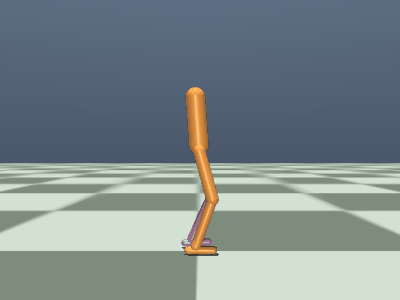

In [8]:
import imageio
from IPython.display import Image, display

def grabar(politica, ruta, pasos=250, cada=2, semilla=0):
    camara = ZancudoMoldeado(render_mode="rgb_array")
    observacion, info = camara.reset(seed=semilla)
    fotos = []
    for paso in range(pasos):
        observacion, recompensa, terminado, truncado, info = camara.step(politica(observacion))
        if paso % cada == 0:
            fotos.append(camara.render())
        if terminado or truncado:
            break
    camara.close()
    imageio.mimsave(ruta, fotos, fps=round(1 / (0.02 * cada)), loop=0)

os.makedirs("assets", exist_ok=True)
grabar(agentes["completa"], "assets/nb44_completa.gif")
display(Image(filename="assets/nb44_completa.gif"))

Compáralo con el GIF del NB43. Ya no hay saltos ni patadas: Zancudo avanza **bajito**, con el torso **recto como una vela**, sin prisas... Pero mira las piernas con atención. La **morada** (la izquierda) va **siempre detrás**, estirada, y la **naranja** (la derecha) **siempre delante**. En ningún fotograma se cruzan. ¿Eso es andar?


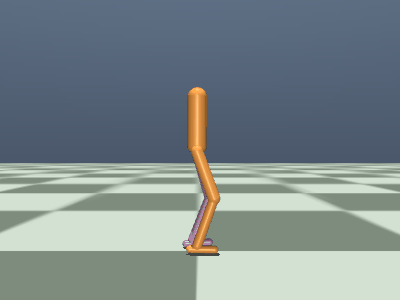

In [9]:
grabar(agentes["sin_vuelo"], "assets/nb44_sin_vuelo.gif")
display(Image(filename="assets/nb44_sin_vuelo.gif"))

`sin_vuelo` se mueve de forma parecida: más saltarín (lo dice la tabla: el 40 % del tiempo en el aire), y otra vez con la pierna morada siempre detrás y la naranja siempre delante.

### ¿Anda de verdad?

Cuando ves algo raro en un GIF, **mídelo** (si no, es solo una impresión). Una función que juega 10 segundos y, para **cada pie**, mide tres cosas:

- qué porcentaje del tiempo **toca el suelo**;
- cuántas veces **aterriza** (pasa de estar en el aire a tocar el suelo);
- y a qué velocidad **se desliza** mientras lo toca. Al andar, el pie de apoyo se queda **quieto** en el suelo (deslizamiento ≈ 0) mientras el cuerpo pasa por encima.

Y, además, a qué distancia media va el pie izquierdo del derecho (negativo = el izquierdo va detrás):


In [10]:
def medir_pies(politica, semilla=0, pasos=500):
    entorno = ZancudoMoldeado()
    observacion, info = entorno.reset(seed=semilla)
    contactos, aterrizajes, deslizamientos, separaciones = [], [0, 0], [[], []], []
    antes_x, antes_toca = None, None
    for paso in range(pasos):
        observacion, recompensa, terminado, truncado, info = entorno.step(politica(observacion))
        toca = entorno.pies_en_el_suelo()
        x = [entorno.datos.geom_xpos[pie][0] for pie in entorno.pies]    # posición hacia delante de cada pie
        if antes_x is not None:
            for k in range(2):                                           # k = 0: derecho, k = 1: izquierdo
                if toca[k] and antes_toca[k]:                            # sigue apoyado: ¿se ha movido?
                    deslizamientos[k].append(abs(x[k] - antes_x[k]) / 0.02)
                if toca[k] and not antes_toca[k]:                        # estaba en el aire y ahora toca
                    aterrizajes[k] += 1
        contactos.append(toca)
        separaciones.append(x[1] - x[0])
        antes_x, antes_toca = x, toca
    contactos = 100 * np.mean(contactos, axis=0)                         # % del tiempo, por pie (NB27: axis)
    return contactos, aterrizajes, [np.mean(d) for d in deslizamientos], np.mean(separaciones)

In [11]:
print(f"{'agente':>20} | {'% toca (der / izq)':>18} | {'aterrizajes':>11} | {'desliza m/s':>11} | {'izq − der (m)':>13}")
for nombre, politica in agentes.items():
    c, a, d, sep = medir_pies(politica)
    print(f"{nombre:>20} | {c[0]:8.0f} / {c[1]:<7.0f} | {a[0]:4d} / {a[1]:<4d} | {d[0]:4.2f} / {d[1]:<4.2f} | {sep:13.2f}")

              agente | % toca (der / izq) | aterrizajes | desliza m/s | izq − der (m)


  NB43 (sin moldear) |       17 / 14      |   20 / 32   | 0.19 / 1.07 |         -0.70


            completa |       54 / 55      |   68 / 125  | 0.38 / 0.85 |         -0.96


           sin_vuelo |       20 / 48      |   43 / 116  | 0.17 / 0.83 |         -1.00


        sin_pie_alto |       15 / 51      |   29 / 112  | 0.55 / 0.56 |         -1.22


               lento |       59 / 67      |   74 / 98   | 0.21 / 0.32 |         -0.89


Lee la fila de `completa`, y fíjate sobre todo en el pie **izquierdo** (el segundo número de cada columna):

- Va **casi un metro por detrás** del derecho (−0,96 m), **de media**: no es que a veces vaya detrás, es que va detrás **siempre**. Y lo mismo en **todas** las filas, incluido el NB43.
- **Aterriza 125 veces** en 10 segundos: ¡12 veces y media por segundo! No son pasos: son **saltitos** minúsculos.
- Mientras toca el suelo, **se desliza a 0,85 m/s**, casi la velocidad del cuerpo (0,99). Ese pie no se apoya y deja pasar el cuerpo por encima: **va a rastras**, patinando detrás del robot.

O sea: Zancudo **no anda**. Lleva la pierna derecha siempre delante, la izquierda siempre detrás, arrastrándola a saltitos, como un niño que juega a los caballitos (o como quien empuja un patinete). Es un **galope**, no un andar: al andar, las piernas se **turnan** (una apoya mientras la otra avanza, y luego al revés), y el pie apoyado se queda **quieto** en el suelo.

¿Y por qué? Porque **nada en la recompensa lo prohíbe**. Repasa los cinco términos: va a 1 m/s ✅, recto ✅, casi siempre hay algún pie tocando el suelo ✅ (¡el de atrás, arrastrándose!), los pies van bajos ✅, sin tirones ✅. Cumple **todo** lo que le pedimos. Es la ley de Goodhart (sección 2) otra vez, y fíjate en que allí ya avisábamos: "si castigas levantar el pie, quizá aprenda a **arrastrar los pies**". Pues eso.

Y en un robot real sería un problema serio: arrastrar un pie lo **desgasta**, y depende por completo del **rozamiento** del suelo, que en la simulación es un número fijo y en el mundo real cambia de una baldosa a una alfombra (el reality gap, NB02). La solución es la de siempre: **pedirlo**.


## 8 · Turnarse las piernas

¿Cómo se le pide a un robot que **alterne** las piernas? Aquí viene a ayudarnos una decisión de diseño del NB43 que hasta ahora no habíamos usado: el **reloj de fase**. Zancudo ve en su observación el seno y el coseno de un ángulo que da una vuelta cada 0,8 segundos (NB36, NB43). Hasta ahora, ese reloj no servía para nada: nadie le pedía seguir un ritmo. Vamos a dárselo:

- En la **primera media vuelta** del reloj (cuando el seno es positivo), queremos el pie **derecho** en el suelo y el **izquierdo** en el aire, avanzando.
- En la **segunda media vuelta** (seno negativo), al revés.
- En los **cambios** (seno cerca de 0), los dos valen: es el **apoyo doble**, el instante en que, al andar, los dos pies tocan el suelo a la vez.

El término nuevo vale 1 si **los dos** pies están donde toca, 0,5 si solo uno, y 0 si ninguno. Así, el reloj marca el **ritmo** (un paso con cada pierna cada 0,8 s) y la política aprende a seguirlo. Es la idea que usan muchos de los robots con patas de los artículos modernos: una **recompensa de marcha periódica**, guiada por un reloj.

Lo programé como una **subclase** de `ZancudoMoldeado` (que, a su vez, es subclase de `Zancudo`: tres generaciones de herencia, NB25), en `zancudo_alterno.py`:


In [12]:
import zancudo_alterno
from zancudo_alterno import ZancudoAlterno

print(inspect.getsource(ZancudoAlterno))

class ZancudoAlterno(ZancudoMoldeado):

    def __init__(self, peso_alterna=1.0, **kwargs):
        super().__init__(**kwargs)
        self.peso_alterna = peso_alterna

    def pies_deseados(self):
        # el mismo reloj que ve la política (NB43): una vuelta cada 0,8 s
        seno = np.sin(2 * np.pi * self.pasos * self.dt / 0.8)
        if seno > 0.3:
            return [True, False]       # media vuelta: apoya el derecho, el izquierdo en el aire
        if seno < -0.3:
            return [False, True]       # la otra media: al revés
        return None                    # en los cambios, los dos valen (apoyo doble)

    def step(self, accion):
        observacion, recompensa, caido, truncado, info = super().step(accion)
        deseados = self.pies_deseados()
        if deseados is None:
            r_alterna = 1.0
        else:
            tocan = self.pies_en_el_suelo()
            r_alterna = np.mean([t == d for t, d in zip(tocan, deseados)])   # 1, 0,5 o 0
        recompensa =

Dos métodos:

- `pies_deseados` mira el reloj (el **mismo** que ve la política: `self.pasos * self.dt / 0.8` vueltas) y dice qué pies **deberían** tocar el suelo ahora: `[True, False]` (solo el derecho), `[False, True]` (solo el izquierdo), o `None` en los cambios (vale cualquier cosa).
- `step` llama al `step` de su madre (que ya calcula los cinco términos del `ZancudoMoldeado`) y le **suma** el término nuevo. `t == d` es `True` si el pie está donde debe; la media de dos `True`/`False` es 1, 0,5 o 0 (NB27: `True` cuenta como 1).

Lo entrené dos veces, con peso 0,5 (`alterna_05`) y con peso 1 (`alterna_1`), con el mismo script (que ahora sabe elegir el entorno según el nombre de la variante):


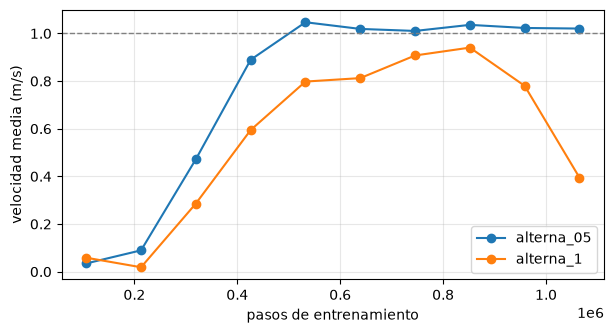

In [13]:
# (pasos, nota, desviación, distancia en m, duración en pasos) de cada tramo, como en la sección 5
alterna_05 = [(106_496, 60.2, 3.0, 0.69, 60.6), (212_992, 896.2, 31.7, 1.79, 1000.0), (319_488, 1103.2, 12.8, 9.44, 1000.0),
              (425_984, 1314.1, 21.1, 17.79, 1000.0), (532_480, 1443.1, 12.2, 20.94, 1000.0), (638_976, 1482.8, 13.4, 20.38, 1000.0),
              (745_472, 1518.9, 8.2, 20.21, 1000.0), (851_968, 1543.8, 10.9, 20.72, 1000.0), (958_464, 1569.1, 5.3, 20.46, 1000.0),
              (1_064_960, 1572.6, 6.8, 20.41, 1000.0)]
alterna_1 = [(106_496, 161.9, 19.6, 1.17, 108.4), (212_992, 935.3, 12.0, 0.37, 1000.0), (319_488, 1214.8, 40.5, 5.72, 1000.0),
             (425_984, 1497.0, 29.2, 11.89, 1000.0), (532_480, 1727.0, 8.3, 15.96, 1000.0), (638_976, 1782.5, 13.9, 16.25, 1000.0),
             (745_472, 1819.4, 14.7, 18.15, 1000.0), (851_968, 1870.8, 7.3, 18.81, 1000.0), (958_464, 1520.7, 724.5, 15.6, 814.4),
             (1_064_960, 801.7, 899.6, 7.9, 437.4)]

plt.figure(figsize=(7, 3.5))
for nombre, registro in [("alterna_05", alterna_05), ("alterna_1", alterna_1)]:
    plt.plot([p for p, *resto in registro], [x / 20 for p, nota, d, x, dur in registro], marker="o", label=nombre)
plt.axhline(1.0, color="gray", ls="--", lw=1)
plt.xlabel("pasos de entrenamiento")
plt.ylabel("velocidad media (m/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Los dos llegan a ~1 m/s. Y `alterna_1` nos regala otra vez el **colapso** del NB43: en sus dos últimos tramos se derrumba (de 1.871 puntos a 802, con caídas). Por suerte, el script guarda **el mejor** (el de los 851.968 pasos), que es el que vamos a examinar.

Para saber si **turna las piernas**, además de lo que ya medimos hace falta una medida nueva: ¿**se cruzan** alguna vez? Si las piernas se turnan, el pie izquierdo tiene que ir **delante** la mitad del tiempo, y la separación (izquierdo − derecho) tiene que cambiar de signo en cada paso:


In [14]:
def contar_cruces(politica, semilla=0, pasos=500):
    entorno = ZancudoMoldeado()
    observacion, info = entorno.reset(seed=semilla)
    separaciones = []
    for paso in range(pasos):
        observacion, recompensa, terminado, truncado, info = entorno.step(politica(observacion))
        x_der, x_izq = [entorno.datos.geom_xpos[pie][0] for pie in entorno.pies]
        separaciones.append(x_izq - x_der)
    signos = np.sign(separaciones)                      # +1 si el izquierdo va delante, −1 si va detrás (NB27)
    cruces = int(np.sum(signos[1:] != signos[:-1]))     # cuántas veces cambia el signo
    return cruces, 100 * np.mean(np.array(separaciones) > 0)

In [15]:
agentes["alterna_05"] = cargar("moldeado_alterna_05_mejor", "ZancudoAlterno-v0", peso_alterna=0.5)
agentes["alterna_1"] = cargar("moldeado_alterna_1_mejor", "ZancudoAlterno-v0", peso_alterna=1.0)

for nombre in ["completa", "alterna_05", "alterna_1"]:
    m = medir_forma(agentes[nombre])
    cruces, delante = contar_cruces(agentes[nombre])
    print(f"{nombre:>10}: {m['velocidad']:.2f} m/s | aire {m['aire']:4.1f} % | pie máx {m['pie_max']:.2f} m"
          f" | las piernas se cruzan {cruces} veces | el izquierdo va delante el {delante:.0f} % del tiempo")

  completa: 0.99 m/s | aire 18.2 % | pie máx 0.14 m | las piernas se cruzan 0 veces | el izquierdo va delante el 0 % del tiempo


alterna_05: 1.01 m/s | aire 33.0 % | pie máx 0.30 m | las piernas se cruzan 2 veces | el izquierdo va delante el 1 % del tiempo


 alterna_1: 0.94 m/s | aire 29.0 % | pie máx 0.51 m | las piernas se cruzan 0 veces | el izquierdo va delante el 0 % del tiempo


Los dos cumplen el objetivo de velocidad... pero las piernas **casi no se cruzan** (2 veces y 0 veces en 10 segundos), y el pie izquierdo va delante el 1 % y el 0 % del tiempo, igual que antes. **Siguen galopando.**

Y fíjate en otra cosa: han **empeorado** en lo que ya teníamos. Vuelan más (33 % y 29 %, frente al 18 % de `completa`) y vuelven a levantar el pie (0,30 m y **0,51 m**, cuando `completa` no pasaba de 0,14). El término nuevo **tira** en contra de los viejos: para cobrar el premio de alternar, les sale a cuenta pagar algo de castigo por pie alto. Por eso `alterna_1`, con el peso más grande, levanta más el pie: **los pesos deciden quién gana** cuando dos términos se contradicen (sección 2, peligro número 2).

¿Qué ha pasado? Mira bien qué le pedimos: "en esta media vuelta, que toque el suelo el pie derecho; en la otra, el izquierdo". Y eso se puede cumplir **sin cruzar las piernas**: basta con pisar con el de delante, luego con el de atrás, luego con el de delante... siempre en el mismo orden de delante a atrás. Un galope con ritmo. Le pedimos **turnar los apoyos**, y turnó los apoyos. No le pedimos que **el pie que vuela adelante al que apoya**, que es lo que de verdad define andar.

Es la ley de Goodhart por **segunda vez en el mismo notebook**, y no es casualidad: es el día a día del oficio. Moldear una recompensa es un bucle: **pides → entrenas → miras → descubres la trampa → la cierras → vuelves a entrenar**. Los equipos que hacen andar robots de verdad pasan por este bucle decenas de veces.

### Segundo intento: que el pie que vuela adelante

Toca pedirlo **directamente**. Al andar, la distancia entre los pies (izquierdo − derecho) **oscila**: en la primera media vuelta, el izquierdo vuela y pasa de ir 20 cm **detrás** a ir 20 cm **delante**; en la segunda, el derecho lo adelanta y la distancia vuelve a −20 cm. Esa oscilación es una onda, y ya sabemos dibujarla con el reloj (NB36): **−0,2 × cos(fase)**.

Así que el término nuevo es... ¡otra **campana**! La de la sección 3, pero en vez de "velocidad cerca de 1 m/s", "separación de los pies cerca de la que marca la onda en este instante". Es una nueva subclase, `ZancudoZancada`, hija de `ZancudoAlterno` (que conserva su término de alternar, con peso 0,5):


In [16]:
from zancudo_alterno import ZancudoZancada

print(inspect.getsource(ZancudoZancada))

class ZancudoZancada(ZancudoAlterno):
    # NB44, sección 8, segundo intento: el pie que vuela debe ADELANTAR al que apoya

    def __init__(self, peso_zancada=1.0, peso_alterna=0.5, **kwargs):
        super().__init__(peso_alterna=peso_alterna, **kwargs)
        self.peso_zancada = peso_zancada

    def separacion_deseada(self):
        # distancia (izquierdo − derecho) que queremos ahora: de −0,2 m a +0,2 m en la primera
        # media vuelta (el izquierdo vuela y adelanta) y de vuelta a −0,2 m en la segunda
        fase = 2 * np.pi * self.pasos * self.dt / 0.8
        return -0.2 * np.cos(fase)

    def step(self, accion):
        observacion, recompensa, caido, truncado, info = super().step(accion)
        x_der, x_izq = [self.datos.geom_xpos[pie][0] for pie in self.pies]
        separacion = x_izq - x_der
        r_zancada = np.exp(-((separacion - self.separacion_deseada()) ** 2) / 0.02)    # la campana, otra vez
        recompensa = recompensa + self.peso_zancada * r_zancada
   

A esto se le llama **seguir una referencia**: en vez de premiar un valor fijo (1 m/s), se premia seguir un valor que **cambia con el tiempo** (la separación de la onda). Llevado al extremo, es como se enseña a los robots a moverse imitando a personas: grabas a alguien andando (captura de movimiento) y premias al robot por parecerse a la grabación en cada instante (lo veremos más adelante en el curso).

Entrenado con peso 1 (`zancada_1`) y peso 2 (`zancada_2`):


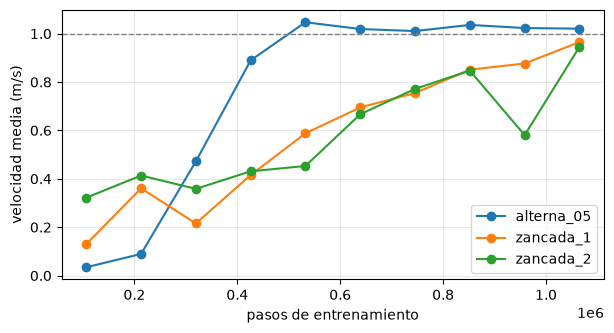

In [17]:
# (pasos, nota, desviación, distancia en m, duración en pasos) de cada tramo
zancada_1 = [(106_496, 544.8, 318.2, 2.6, 273.8), (212_992, 2017.8, 86.7, 7.21, 989.8), (319_488, 1502.7, 559.3, 4.31, 824.0),
             (425_984, 1901.5, 6.3, 8.31, 1000.0), (532_480, 2133.1, 38.0, 11.76, 1000.0), (638_976, 2278.4, 16.9, 13.9, 1000.0),
             (745_472, 2417.6, 16.1, 15.09, 1000.0), (851_968, 2583.4, 13.9, 17.02, 1000.0), (958_464, 2642.7, 4.3, 17.53, 1000.0),
             (1_064_960, 2579.8, 160.5, 19.3, 973.4)]
zancada_2 = [(106_496, 1922.6, 1048.6, 6.44, 629.8), (212_992, 3048.2, 16.1, 8.27, 1000.0), (319_488, 2985.4, 26.5, 7.17, 1000.0),
             (425_984, 2990.5, 7.4, 8.62, 1000.0), (532_480, 3068.4, 16.1, 9.06, 1000.0), (638_976, 3227.2, 6.8, 13.34, 1000.0),
             (745_472, 3359.7, 12.9, 15.43, 1000.0), (851_968, 3470.2, 8.6, 16.94, 1000.0), (958_464, 2223.4, 1586.9, 11.61, 639.6),
             (1_064_960, 3587.6, 8.9, 18.9, 1000.0)]

plt.figure(figsize=(7, 3.5))
for nombre, registro in [("alterna_05", alterna_05), ("zancada_1", zancada_1), ("zancada_2", zancada_2)]:
    plt.plot([p for p, *resto in registro], [x / 20 for p, nota, d, x, dur in registro], marker="o", label=nombre)
plt.axhline(1.0, color="gray", ls="--", lw=1)
plt.xlabel("pasos de entrenamiento")
plt.ylabel("velocidad media (m/s)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Aprenden **más despacio** que `alterna_05` (a igual número de pasos, van más lentos): la tarea es más difícil, porque ahora hay que mover las piernas **de una forma concreta**, no de cualquiera. Y `zancada_2` vuelve a darnos un susto (un examen con caídas a los 958.464 pasos) del que se recupera. Sus mejores exámenes (los que guarda el script) rondan los 0,9 m/s: un poco por debajo del objetivo. ¿Han aprendido a andar?


In [18]:
agentes["zancada_1"] = cargar("moldeado_zancada_1_mejor", "ZancudoZancada-v0", peso_zancada=1.0)
agentes["zancada_2"] = cargar("moldeado_zancada_2_mejor", "ZancudoZancada-v0", peso_zancada=2.0)

for nombre in ["completa", "alterna_05", "zancada_1", "zancada_2"]:
    m = medir_forma(agentes[nombre])
    cruces, delante = contar_cruces(agentes[nombre])
    c, a, d, sep = medir_pies(agentes[nombre])
    print(f"{nombre:>10}: {m['velocidad']:.2f} m/s | aire {m['aire']:4.1f} % | se cruzan {cruces:2d} veces | izq. delante {delante:3.0f} %"
          f" | desliza {d[0]:.2f} / {d[1]:.2f} m/s | tirones {m['cambio']:.2f}")

  completa: 0.99 m/s | aire 18.2 % | se cruzan  0 veces | izq. delante   0 % | desliza 0.38 / 0.85 m/s | tirones 0.26


alterna_05: 1.01 m/s | aire 33.0 % | se cruzan  2 veces | izq. delante   1 % | desliza 0.28 / 0.48 m/s | tirones 0.65


 zancada_1: 0.85 m/s | aire 28.6 % | se cruzan 25 veces | izq. delante  50 % | desliza 0.20 / 0.12 m/s | tirones 0.43


 zancada_2: 0.91 m/s | aire 32.6 % | se cruzan 25 veces | izq. delante  50 % | desliza 0.30 / 0.17 m/s | tirones 0.72


**¡Ahora sí!** Mira las columnas nuevas:

- Las piernas **se cruzan 25 veces** en 10 segundos. El reloj da una vuelta cada 0,8 s, y en cada vuelta las piernas se cruzan **dos** veces (una el izquierdo adelanta al derecho, otra al revés): 10 / 0,8 × 2 = **25**. ¡Exacto! Siguen el ritmo del reloj al pie de la letra.
- El pie izquierdo va delante **el 50 %** del tiempo: las dos piernas trabajan **igual**, por turnos.
- Los pies apenas se **deslizan** (0,20 y 0,12 m/s en `zancada_1`, frente a los 0,85 m/s del pie arrastrado de `completa`): el pie apoyado **se queda en el suelo** mientras el cuerpo pasa por encima. Eso es andar.

No es perfecto, y hay que decirlo: van a 0,85-0,91 m/s (un poco por debajo de lo pedido), todavía pasan casi un 30 % del tiempo con los dos pies en el aire (dan **saltitos** al cambiar de pie), y van con más tirones que `completa`. Cada término nuevo ha costado algo en los demás. Pero el cambio de **galope** a **andar** está conseguido, y lo hemos **medido**, no solo visto.

Nos quedamos con `zancada_1`: alterna igual que `zancada_2`, pero vuela menos, se desliza menos y da menos tirones. Míralo:


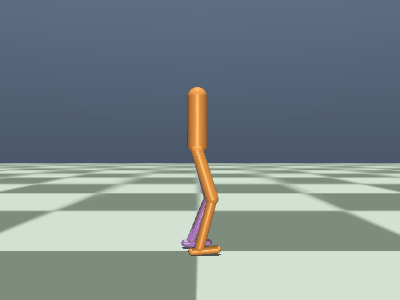

In [19]:
grabar(agentes["zancada_1"], "assets/nb44_zancada.gif")
display(Image(filename="assets/nb44_zancada.gif"))

Compáralo con el GIF de `completa`: ahora la pierna **morada** y la **naranja** se **turnan**, una delante y luego la otra, con el torso recto y pasos cortos (40 cm, lo que marca la onda de −0,2 a +0,2 m). Es, por fin, un robot que **anda**.


## 9 · Lo que nos llevamos

1. **El agente hace lo que le pagas, no lo que quieres.** Con la recompensa del NB43 corría; con la campana de velocidad, galopaba; pidiéndole que alternara los apoyos, galopaba con ritmo; solo al pedirle que el pie que vuela **adelante** al que apoya, anduvo. Tres trampas en un notebook (Goodhart, NB04).
2. **Para seguir un objetivo, una campana.** e^(−diferencia² / ancho) vale 1 en el objetivo y cae al alejarse. Sirve para velocidades, inclinaciones, separaciones... y para referencias que cambian con el tiempo.
3. **El ancho de la campana importa.** Con objetivo 0,5 m/s, quedarse quieto seguía cobrando el 37 % del premio, y `lento` tardó medio millón de pasos en salir de la trampa de sobrevivir.
4. **Los términos se pelean.** Añadir uno puede empeorar lo que vigilaban otros (los `alterna` volvieron a levantar el pie). Los pesos deciden quién gana.
5. **Ablación**: quita cada pieza y comprueba que empeora justo lo que vigilaba. Es la forma de demostrar que cada término sirve.
6. **No te fíes de la nota: mide lo que querías.** Las notas de variantes distintas no se comparan. Lo que se compara es la velocidad, el tiempo en el aire, la altura de los pies, los cruces de piernas, el deslizamiento... Y **mira los GIF**: el galope lo descubrimos mirando.
7. **Moldear es un bucle**: pedir → entrenar → mirar y medir → descubrir la trampa → cerrarla → volver a entrenar.
8. **Guarda puntos de control** (y el mejor, NB35): un reinicio de la Pi no nos costó nada; dos colapsos (`alterna_1`, y casi `zancada_2`) tampoco.


## 10 · Resumen de la lección

1. El Zancudo del NB43 corría a 4,25 m/s, el 69 % del tiempo en el aire, con patadas de medio metro: la recompensa no tenía techo ni decía **cómo** moverse.
2. **Moldear la recompensa** = añadir términos con pesos. Peligros: cada término es una trampa nueva, los pesos importan y la trampa de sobrevivir acecha.
3. `ZancudoMoldeado` (herencia, NB25): campana de velocidad (1 m/s), torso recto, vida 0,2, castigos por volar, por pie alto (> 15 cm) y por tirones.
4. **Ablación** (completa, sin_vuelo, sin_pie_alto, lento): todos a la velocidad pedida; quitar el castigo de vuelo dobla el tiempo en el aire (18 → 40 %); quitar pie alto + suavidad devuelve las patadas (0,79 m) y cuadruplica los tirones.
5. Pero **ninguno anda**: la pierna izquierda va siempre detrás, arrastrándose (se desliza a 0,85 m/s). Es un **galope**.
6. Primer arreglo, **alternar apoyos** con el reloj de fase: sigue galopando, con ritmo (Goodhart otra vez), y los términos se pelean.
7. Segundo arreglo, **seguir una referencia** de separación de los pies (−0,2 × cos(fase), otra campana): las piernas se cruzan 25 veces en 10 s, justo el ritmo del reloj, cada pie va delante la mitad del tiempo y el pie apoyado no se desliza. **Anda.**

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Moldear la recompensa (*reward shaping*)** | Añadir términos y pesos a la recompensa para conseguir un comportamiento concreto. |
| **Término / peso** | Cada pieza de la recompensa / cuánto cuenta. |
| **Núcleo exponencial (campana)** | e^(−diferencia² / ancho): vale 1 en el objetivo y cae al alejarse. |
| **Seguir (*tracking*) un objetivo** | Premiar la cercanía a un valor pedido, no el máximo. |
| **Castigo por tirones (*action rate*)** | Castigar el cambio de la acción entre decisiones seguidas. |
| **Estudio de ablación** | Quitar piezas una a una para ver qué aporta cada una. |
| **Andar / correr** | Siempre al menos un pie en el suelo / con fases en el aire. |
| **Galope** | Marcha en la que la misma pierna va siempre delante. |
| **Apoyo doble** | El instante en que, al andar, los dos pies tocan el suelo. |
| **Recompensa de marcha periódica** | Premiar que los pies sigan un ritmo marcado por un reloj de fase. |
| **Seguir una referencia** | Premiar la cercanía a un valor que cambia con el tiempo. |


## 11 · Ejercicios

**E1.** Con objetivo 1 m/s y ancho 0,25, ¿cuánto paga la campana de velocidad a 0,5, 1,5, 2 y 4 m/s? ¿Por qué 0,5 y 1,5 pagan lo mismo?

**E2.** En `lento` (objetivo 0,5 m/s), ¿cuánto cobraría por paso quedarse quieto y recto si la campana tuviera ancho **0,05** en vez de 0,25? ¿Y qué pierde una campana tan estrecha? (Pista: calcula cuánto paga ir a 0,3 m/s con cada ancho.)

**E3.** ¿Cuánto siguen el reloj los agentes? Juega 500 pasos de cada uno en `ZancudoAlterno()` (sea cual sea su recompensa, la `info` trae `r_alterna`) y calcula la media de `info["r_alterna"]`. Compara `completa`, `alterna_05`, `alterna_1` y `zancada_1`.

**E4.** Graba el GIF de `sin_pie_alto` y compáralo con el de `completa`. ¿Se ven las patadas?

**E5.** **Reto.** Escribe una subclase `ZancudoSinPatinar` de `ZancudoZancada` que **castigue** que el pie apoyado se deslice (la velocidad hacia delante del pie mientras toca el suelo), y entrénala con `entrenar_moldeado.py` (añadiendo la variante). ¿Baja el deslizamiento? ¿Cuesta algo en lo demás?


<details>
<summary>▶ Solución E1</summary>

```python
for v in [0.5, 1.5, 2, 4]:
    print(v, np.exp(-(v - 1.0) ** 2 / 0.25))
```

0,5 → **0,37**; 1,5 → **0,37**; 2 → **0,018**; 4 → **0,0000000000000002** (cero, a efectos prácticos). 0,5 y 1,5 pagan lo mismo porque la campana es **simétrica**: solo importa la diferencia **al cuadrado**, y (−0,5)² = (+0,5)² = 0,25. Ir medio metro por segundo de menos se paga igual que ir medio de más.
</details>

<details>
<summary>▶ Solución E2</summary>

Quieto, la diferencia con el objetivo es 0,5, al cuadrado 0,25: con ancho 0,05, e^(−0,25 / 0,05) = e⁻⁵ ≈ **0,007**. Más recto 0,3 y vida 0,2: **≈ 0,51** por paso, frente a **0,87** con ancho 0,25. Andar a 0,5 m/s sigue pagando 1,5: ahora andar paga **el triple** que quedarse quieto (antes, menos del doble). La trampa de sobrevivir sería mucho menos atractiva.

¿Qué se pierde? A 0,3 m/s (diferencia 0,2, al cuadrado 0,04), la campana ancha paga e^(−0,04 / 0,25) ≈ **0,85**, y la estrecha, e^(−0,04 / 0,05) ≈ **0,45**. Con la estrecha, el premio solo empieza a notarse **muy cerca** del objetivo: un agente que todavía va despacio recibe muy poca "pista" de hacia dónde mejorar (la pendiente de la campana, lejos del centro, es casi plana: NB16). Por eso hay quien combina dos campanas, una ancha para guiar y una estrecha para afinar.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
for nombre in ["completa", "alterna_05", "alterna_1", "zancada_1"]:
    entorno = ZancudoAlterno()
    observacion, info = entorno.reset(seed=0)
    valores = []
    for paso in range(500):
        observacion, recompensa, terminado, truncado, info = entorno.step(agentes[nombre](observacion))
        valores.append(info["r_alterna"])
    print(nombre, round(np.mean(valores), 2))
```

`completa` **0,56**, `alterna_05` **0,62**, `alterna_1` **0,67**, `zancada_1` **0,85**. Los `alterna` siguen el reloj algo mejor que `completa`, pero poco: galopando con ritmo no se puede ir mucho más allá. `zancada_1`, que sí anda, lo sigue mucho mejor (y eso que el término de alternar pesa lo mismo que en `alterna_05`). Curiosidad: quedarse quieto con los dos pies en el suelo saca unos 0,57 (en los cambios del reloj vale cualquier cosa, y el resto del tiempo tiene uno de los dos pies "bien"): ¡`completa` no sigue el reloj mejor que un robot quieto!
</details>

<details>
<summary>▶ Solución E4</summary>

```python
grabar(agentes["sin_pie_alto"], "assets/nb44_sin_pie_alto.gif")
display(Image(filename="assets/nb44_sin_pie_alto.gif"))
```

Sí: sin el castigo de pie alto, la pierna que avanza vuelve a subir muchísimo (0,79 m en la tabla de la sección 6) y los movimientos son mucho más bruscos (sin el castigo de suavidad). Va a la misma velocidad que `completa`: las patadas no le sirven para nada, simplemente nadie le dice que no las dé.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
# en zancudo_alterno.py (o en un fichero nuevo que importe ZancudoZancada)
class ZancudoSinPatinar(ZancudoZancada):

    def __init__(self, peso_patinar=0.5, **kwargs):
        super().__init__(**kwargs)
        self.peso_patinar = peso_patinar

    def reset(self, seed=None, options=None):
        resultado = super().reset(seed=seed, options=options)
        self.x_pies_antes = [self.datos.geom_xpos[pie][0] for pie in self.pies]
        return resultado

    def step(self, accion):
        observacion, recompensa, caido, truncado, info = super().step(accion)
        x_pies = [self.datos.geom_xpos[pie][0] for pie in self.pies]
        tocan = self.pies_en_el_suelo()
        patinar = sum(abs(x - x0) / self.dt for x, x0, t in zip(x_pies, self.x_pies_antes, tocan) if t)
        self.x_pies_antes = x_pies
        recompensa = recompensa - self.peso_patinar * patinar
        info.update(patinar=patinar)
        return observacion, recompensa, caido, truncado, info

gym.register(id="ZancudoSinPatinar-v0", entry_point=ZancudoSinPatinar)
```

En `entrenar_moldeado.py`, añade `"sin_patinar": dict(peso_patinar=0.5)` a `VARIANTES` y haz que el nombre `sin_patinar` elija `"ZancudoSinPatinar-v0"`. Después, mide con `medir_pies`. Lo esperable: menos deslizamiento, y quizá pasos más cortos o un poco más lentos (cada castigo nuevo cuesta algo). Pero el resultado **solo lo sabrás entrenándolo**: esa es la lección del notebook. Ojo con el peso: un castigo de deslizamiento muy fuerte puede hacer que lo más barato sea... no apoyar nunca el pie (¡volar!), o no moverse.
</details>


## 12 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Zancudo ya anda a la velocidad que le pedimos. Pero en el NB41 vimos lo frágiles que son las políticas entrenadas en un mundo perfecto, y en el NB43, cómo sufrían con los empujones. En el **NB45** lo haremos **robusto**: lo entrenaremos en mundos que cambian (masas distintas, suelos más o menos resbaladizos, motores más flojos, sensores con ruido y retraso) y recibiendo **empujones** mientras aprende. Es la **aleatorización de dominio** (NB02), la técnica que más ha hecho por llevar robots de la simulación a la realidad.
